In [7]:
import pandas as pd
import numpy as np
import os
import glob
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

print("Gerekli tüm kütüphaneler yüklendi.")

Gerekli tüm kütüphaneler yüklendi.


In [8]:
# Klasör ismini buraya tam olarak yaz (indirdiğin klasör ismiyle aynı olmalı)
base_path = 'big-ideas-lab-glycemic-variability-and-wearable-device-data-1.0.0'

# Klasör içindeki dosyaları bulalım
if os.path.exists(base_path):
    all_files = glob.glob(os.path.join(base_path, "**/*.csv"), recursive=True)
    print(f"Toplam bulunan CSV dosyası sayısı: {len(all_files)}")
    # Klasör yapısını görelim
    for i, f in enumerate(all_files[:5]):
        print(f"Örnek dosya yolu {i+1}: {f}")
else:
    print("HATA: Klasör bulunamadı! Lütfen ZIP'ten çıkardığınız klasörün ismini kontrol edin.")

HATA: Klasör bulunamadı! Lütfen ZIP'ten çıkardığınız klasörün ismini kontrol edin.


In [1]:
import pandas as pd
import os
import glob

# Klasör yolu
base_path = 'cgmacros' 

# Tüm CSV dosyalarını bulalım
csv_files = glob.glob(os.path.join(base_path, "*.csv"))

print(f"--- CGMacros Klasör Analizi ---")
print(f"Bulunan toplam dosya sayısı: {len(csv_files)}")

for f in csv_files:
    # Dosyayı oku (ilk 5 satır)
    df_temp = pd.read_csv(f)
    file_name = os.path.basename(f)
    print(f"\nDosya: {file_name}")
    print(f"Satır/Sütun Sayısı: {df_temp.shape}")
    print(f"Sütun İsimleri: {df_temp.columns.tolist()}")

--- CGMacros Klasör Analizi ---
Bulunan toplam dosya sayısı: 0


In [2]:
import os

# 1. Python şu an nerede?
print(f"Şu anki dizin: {os.getcwd()}")

# 2. Bu dizinde hangi klasörler var?
folders = [d for d in os.listdir() if os.path.isdir(d)]
print(f"Görünen klasörler: {folders}")

# 3. Eğer klasörün içindeyse, dosyaları listele
# Eğer klasör ismin farklıysa aşağıyı ona göre güncelle
possible_path = 'CGMacros_dateshifted365' 
if os.path.exists(possible_path):
    print(f"\n'{possible_path}' klasörü bulundu!")
    print(f"İçindeki dosyalar: {os.listdir(possible_path)}")
else:
    print(f"\nHATA: '{possible_path}' klasörü bulunamadı.")

Şu anki dizin: e:\HbA1cAIDCARE
Görünen klasörler: ['.git', 'aidcare_deep_tuning', 'aidcare_expert_tuning', 'aidcare_tuning', 'cgmacros', '__pycache__']

HATA: 'CGMacros_dateshifted365' klasörü bulunamadı.


In [4]:
import pandas as pd
import os

# Dizinde görünen doğru klasör ismini kullanıyoruz
base_path = 'cgmacros'

print(f"--- {base_path} Klasörü İçerik Analizi ---")

# Klasördeki tüm dosyaları listele
files = os.listdir(base_path)

for file in files:
    file_path = os.path.join(base_path, file)
    
    # Sadece CSV dosyalarını analiz edelim
    if file.endswith('.csv'):
        try:
            # Veriyi yükle (ilk 5 satır yeterli)
            df_temp = pd.read_csv(file_path)
            print(f"\n📄 Dosya: {file}")
            print(f"   - Satır Sayısı: {df_temp.shape[0]}")
            print(f"   - Sütunlar: {df_temp.columns.tolist()}")
            
            # Kritik sütun kontrolü (HbA1c veya Glucose var mı?)
            if any('hba1c' in col.lower() for col in df_temp.columns):
                print("   - ⭐ KRİTİK: Bu dosya hedef (HbA1c) verilerini içeriyor!")
            if any('glucose' in col.lower() for col in df_temp.columns):
                print("   - ⚡ KRİTİK: Bu dosya girdi (Glikoz) verilerini içeriyor!")
                
        except Exception as e:
            print(f"   - ⚠️ {file} okunurken hata oluştu: {e}")

--- cgmacros Klasörü İçerik Analizi ---


In [5]:
import pandas as pd
import os

# Klasör yolu
base_path = 'cgmacros'

print(f"--- {base_path} Klasörü İçerik Detayları ---")

# Klasördeki tüm dosyaları listele
files = os.listdir(base_path)

# Analiz edilecek dosyalar (CSV olanlar)
csv_files = [f for f in files if f.endswith('.csv')]

for file in csv_files:
    file_path = os.path.join(base_path, file)
    try:
        # Verinin sadece ilk birkaç satırını ve sütunlarını okuyoruz
        df_temp = pd.read_csv(file_path)
        
        print(f"\n📄 Dosya: {file}")
        print(f"   - Boyut: {df_temp.shape[0]} satır, {df_temp.shape[1]} sütun")
        print(f"   - Sütunlar: {df_temp.columns.tolist()[:10]}...") # İlk 10 sütunu göster
        
        # Kritik veri kontrolleri
        lower_cols = [c.lower() for c in df_temp.columns]
        
        if 'hba1c' in lower_cols:
            print("   - ⭐ HEDEF DOSYASI: Bu dosya modelin tahmin etmesi gereken HbA1c değerlerini içeriyor.")
        
        if any(x in lower_cols for x in ['glucose', 'glukoz', 'glucose_value']):
            print("   - ⚡ GİRDİ DOSYASI: Bu dosya sensörlerden gelen şeker verilerini içeriyor.")
            
        if any(x in lower_cols for x in ['carbohydrate', 'carb_g', 'calories']):
            print("   - 🍎 BESLENME DOSYASI: R2 skorunu artırmak için kullanabileceğimiz yemek verileri burada.")
            
    except Exception as e:
        print(f"   - ⚠️ {file} okunurken bir hata oluştu: {e}")

--- cgmacros Klasörü İçerik Detayları ---


In [6]:
import pandas as pd
import os
import glob

# Ana dizin
base_path = 'cgmacros'

print(f"--- {base_path} Klasörü Detaylı Dosya Taraması ---")

# Alt klasörler dahil tüm CSV dosyalarını bul
all_csv_files = glob.glob(os.path.join(base_path, "**/*.csv"), recursive=True)

if not all_csv_files:
    print("HATA: Klasör içinde CSV dosyası bulunamadı. Lütfen ZIP içeriğinin doğru çıkarıldığından emin olun.")
else:
    print(f"Toplam {len(all_csv_files)} adet veri dosyası bulundu.\n")
    
    for file_path in all_csv_files:
        try:
            # Sadece sütun isimlerini kontrol etmek için ilk satırı oku
            df_headers = pd.read_csv(file_path, nrows=0)
            cols = [c.lower() for c in df_headers.columns]
            file_name = os.path.basename(file_path)
            
            print(f"📄 Dosya: {file_name}")
            print(f"   - Yol: {file_path}")
            
            # Veri tipi tespiti
            if 'hba1c' in cols:
                print("   - ⭐ HEDEF (Target): HbA1c değerlerini içeren ana dosya bulundu!")
            if any(x in cols for x in ['glucose', 'glucose_value', 'glukoz']):
                print("   - ⚡ GİRDİ (Feature): Sensör (CGM) verilerini içeren dosya bulundu!")
            if any(x in cols for x in ['carb', 'calorie', 'protein']):
                print("   - 🍎 EKSTRA: Beslenme verileri bulundu (R2 skorunu artırmak için kritik).")
                
        except Exception as e:
            print(f"   - ⚠️ {os.path.basename(file_path)} okunamadı: {e}")

--- cgmacros Klasörü Detaylı Dosya Taraması ---
Toplam 4 adet veri dosyası bulundu.

📄 Dosya: DataDictionary_Bio.csv
   - Yol: cgmacros\cgmacros-a-scientific-dataset-for-personalized-nutrition-and-diet-monitoring-1.0.0\DataDictionary_Bio.csv
📄 Dosya: DataDictionary_CGMacros-00X.csv
   - Yol: cgmacros\cgmacros-a-scientific-dataset-for-personalized-nutrition-and-diet-monitoring-1.0.0\DataDictionary_CGMacros-00X.csv
📄 Dosya: DataDictionary_Gut_Health_Test.csv
   - Yol: cgmacros\cgmacros-a-scientific-dataset-for-personalized-nutrition-and-diet-monitoring-1.0.0\DataDictionary_Gut_Health_Test.csv
📄 Dosya: DataDictionary_Microbes.csv
   - Yol: cgmacros\cgmacros-a-scientific-dataset-for-personalized-nutrition-and-diet-monitoring-1.0.0\DataDictionary_Microbes.csv


In [7]:
import pandas as pd
import os

# Yol tanımı (Sözlüklerin olduğu yerin bir üst klasörünü veya 'data' klasörünü kontrol et)
base_data_path = r'cgmacros\cgmacros-a-scientific-dataset-for-personalized-nutrition-and-diet-monitoring-1.0.0'

# Önemli: Bu klasörün içinde 'data' veya 'processed' gibi bir alt klasör olup olmadığına bak
# Eğer veriler ana dizindeyse isimleri tahmin edip yüklüyoruz:
try:
    # Bio verisi (HbA1c burada olmalı)
    df_bio = pd.read_csv(os.path.join(base_data_path, 'Bio.csv')) 
    # CGM verisi (Şeker ölçümleri burada)
    df_cgm = pd.read_csv(os.path.join(base_data_path, 'CGM.csv'))
    
    print("Gerçek veriler başarıyla yüklendi!")
    print(f"Hasta sayısı: {df_bio['Subject_ID'].nunique()}")
except:
    print("Dosya isimleri farklı olabilir. Lütfen klasördeki diğer CSV isimlerini kontrol et.")

Dosya isimleri farklı olabilir. Lütfen klasördeki diğer CSV isimlerini kontrol et.


In [9]:
import os
import glob

# Ana dizin
base_path = 'cgmacros'

# 'DataDictionary' kelimesini içermeyen tüm CSV dosyalarını tara
all_files = glob.glob(os.path.join(base_path, "**/*.csv"), recursive=True)
real_data_files = [f for f in all_files if "DataDictionary" not in f]

print(f"--- Gerçek Veri Dosyaları Listesi ---")
if not real_data_files:
    print("HATA: Ölçüm verisi içeren CSV dosyası bulunamadı. Lütfen ZIP içeriğini tam çıkardığınızdan emin olun.")
else:
    for i, file in enumerate(real_data_files):
        print(f"{i+1}. {file}")

--- Gerçek Veri Dosyaları Listesi ---
1. cgmacros\cgmacros-a-scientific-dataset-for-personalized-nutrition-and-diet-monitoring-1.0.0\CGMacros_dateshifted365\CGMacros\bio.csv
2. cgmacros\cgmacros-a-scientific-dataset-for-personalized-nutrition-and-diet-monitoring-1.0.0\CGMacros_dateshifted365\CGMacros\gut_health_test.csv
3. cgmacros\cgmacros-a-scientific-dataset-for-personalized-nutrition-and-diet-monitoring-1.0.0\CGMacros_dateshifted365\CGMacros\microbes.csv
4. cgmacros\cgmacros-a-scientific-dataset-for-personalized-nutrition-and-diet-monitoring-1.0.0\CGMacros_dateshifted365\CGMacros\CGMacros-001\CGMacros-001.csv
5. cgmacros\cgmacros-a-scientific-dataset-for-personalized-nutrition-and-diet-monitoring-1.0.0\CGMacros_dateshifted365\CGMacros\CGMacros-002\CGMacros-002.csv
6. cgmacros\cgmacros-a-scientific-dataset-for-personalized-nutrition-and-diet-monitoring-1.0.0\CGMacros_dateshifted365\CGMacros\CGMacros-003\CGMacros-003.csv
7. cgmacros\cgmacros-a-scientific-dataset-for-personalized-nutr

In [11]:
import pandas as pd
import numpy as np
import os
import glob

# Önceki dizin yollarını koruyoruz
base_path = r'cgmacros\cgmacros-a-scientific-dataset-for-personalized-nutrition-and-diet-monitoring-1.0.0\CGMacros_dateshifted365\CGMacros'
cgm_folder_pattern = os.path.join(base_path, 'CGMacros-*', 'CGMacros-*.csv')

def extract_cgm_features(file_path):
    try:
        df = pd.read_csv(file_path)
        df.columns = [c.lower().strip() for c in df.columns] # Boşlukları da temizleyelim
        
        # Olası sütun isimlerini kontrol et
        possible_cols = [c for c in df.columns if 'glucose' in c or 'value' in c or 'gl' == c]
        
        if not possible_cols:
            return None # Sütun bulunamadıysa hata verme, bu dosyayı geç
            
        g_col = possible_cols[0]
        glucose = pd.to_numeric(df[g_col], errors='coerce').dropna()
        
        if len(glucose) < 100: 
            return None # Yetersiz veri
        
        feats = {}
        # Dosya yolundan Subject_ID'yi çek (Örn: CGMacros-001)
        # Klasör yapısına göre: .../CGMacros-001/CGMacros-001.csv
        parent_folder = os.path.basename(os.path.dirname(file_path))
        feats['subject_id'] = parent_folder.lower()
        
        feats['mean_g'] = glucose.mean()
        feats['std_g'] = glucose.std()
        feats['cv'] = (feats['std_g'] / feats['mean_g']) * 100
        feats['tir'] = (len(glucose[(glucose >= 70) & (glucose <= 180)]) / len(glucose)) * 100
        feats['gmi'] = 3.31 + (0.02392 * feats['mean_g'])
        
        return feats
    except Exception as e:
        print(f"Hata oluştu ({os.path.basename(file_path)}): {e}")
        return None

# Dosyaları topla ve işle
cgm_files = glob.glob(cgm_folder_pattern)
all_features = []

print(f"{len(cgm_files)} dosya taranıyor...")
for f in cgm_files:
    res = extract_cgm_features(f)
    if res:
        all_features.append(res)

df_features = pd.DataFrame(all_features)
print(f"Başarıyla işlenen hasta sayısı: {len(df_features)}")

45 dosya taranıyor...
Başarıyla işlenen hasta sayısı: 0


In [12]:
import pandas as pd
import os
import glob

base_path = r'cgmacros\cgmacros-a-scientific-dataset-for-personalized-nutrition-and-diet-monitoring-1.0.0\CGMacros_dateshifted365\CGMacros'
bio_path = os.path.join(base_path, 'bio.csv')

# bio.csv içeriğini ve ID formatını kontrol et
df_bio = pd.read_csv(bio_path)
print("--- bio.csv İlk Satırları ---")
display(df_bio.head(3))

# Klasör isimlerini kontrol et
cgm_folders = glob.glob(os.path.join(base_path, 'CGMacros-*'))
print(f"\nÖrnek Klasör Adı: {os.path.basename(cgm_folders[0]) if cgm_folders else 'Klasör bulunamadı'}")

--- bio.csv İlk Satırları ---


,subject,Age,Gender,BMI,Body weight,Height,Self-identify,A1c PDL (Lab),Fasting GLU - PDL (Lab),Insulin,...,LDL (Cal),VLDL (Cal),Cho/HDL Ratio,Collection time PDL (Lab),#1 Contour Fingerstick GLU,Time (t),#2 Contour Fingerstick GLU,Time (t).1,#3 Contour Fingerstick GLU,Time (t).2
0,1,27,M,22.265239,133.8,65.0,Hispanic/Latino,5.4,91,2.5,...,130,13,2.9,11:06:00 AM,89,9:40,73,12:11,81,13:18
1,2,49,F,30.946742,169.2,62.0,Hispanic/Latino,5.5,93,14.8,...,78,12,2.0,7:38:00 AM,91,7:52,123,9:21,80,10:22
2,3,59,F,26.948690,157.0,64.0,Hispanic/Latino,6.5,118,17.4,...,90,31,2.6,7:25:00 AM,119,7:38,166,9:23,98,10:23



Örnek Klasör Adı: CGMacros-001


In [13]:
import pandas as pd
import numpy as np
import os
import glob
import re

base_path = r'cgmacros\cgmacros-a-scientific-dataset-for-personalized-nutrition-and-diet-monitoring-1.0.0\CGMacros_dateshifted365\CGMacros'

def get_numeric_id(text):
    """Metin içindeki sayıları ayıklar (Örn: 'CGMacros-001' -> 1)"""
    nums = re.findall(r'\d+', str(text))
    return int(nums[0]) if nums else None

def extract_cgm_metrics(file_path):
    try:
        df = pd.read_csv(file_path)
        df.columns = [c.lower().strip() for c in df.columns]
        
        # Glikoz sütununu bul
        g_col = [c for c in df.columns if 'glucose' in c or 'value' in c or 'gl' == c]
        if not g_col: return None
            
        glucose = pd.to_numeric(df[g_col[0]], errors='coerce').dropna()
        if len(glucose) < 100: return None
        
        # Klasör adından ID al (Örn: CGMacros-001 -> 1)
        folder_name = os.path.basename(os.path.dirname(file_path))
        
        return {
            'subject_id': get_numeric_id(folder_name),
            'mean_g': glucose.mean(),
            'std_g': glucose.std(),
            'cv': (glucose.std() / glucose.mean()) * 100,
            'tir': (len(glucose[(glucose >= 70) & (glucose <= 180)]) / len(glucose)) * 100,
            'gmi': 3.31 + (0.02392 * glucose.mean())
        }
    except:
        return None

# CGM verilerini işle
cgm_pattern = os.path.join(base_path, 'CGMacros-*', 'CGMacros-*.csv')
cgm_files = glob.glob(cgm_pattern)
features_list = [extract_cgm_metrics(f) for f in cgm_files]
df_features = pd.DataFrame([f for f in features_list if f is not None])

print(f"İşlenen CGM hasta sayısı: {len(df_features)}")

İşlenen CGM hasta sayısı: 0


In [14]:
import os
import glob

# Ana dizin
base_path = r'cgmacros\cgmacros-a-scientific-dataset-for-personalized-nutrition-and-diet-monitoring-1.0.0\CGMacros_dateshifted365\CGMacros'

# Klasörün varlığını kontrol et
if not os.path.exists(base_path):
    print(f"HATA: '{base_path}' dizini bulunamadı. Lütfen klasör ismini kontrol et.")
else:
    # İçerideki tüm CSV dosyalarını en derine kadar tara
    all_csv_files = glob.glob(os.path.join(base_path, "**", "*.csv"), recursive=True)
    
    # Sadece içinde 'CGMacros-' geçen ve 'DataDictionary' olmayan dosyaları ayıkla
    cgm_data_files = [f for f in all_csv_files if "CGMacros-" in f and "DataDictionary" not in f]
    
    print(f"Dizinde toplam {len(all_csv_files)} CSV dosyası bulundu.")
    print(f"CGM verisi olduğu tahmin edilen dosya sayısı: {len(cgm_data_files)}")
    
    if len(cgm_data_files) > 0:
        print("\nÖrnek ilk 3 dosya yolu:")
        for f in cgm_data_files[:3]:
            print(f"- {f}")
    else:
        print("\nUYARI: CGM verisi içeren dosya bulunamadı. Klasör yapısını manuel kontrol etmelisin.")

Dizinde toplam 48 CSV dosyası bulundu.
CGM verisi olduğu tahmin edilen dosya sayısı: 45

Örnek ilk 3 dosya yolu:
- cgmacros\cgmacros-a-scientific-dataset-for-personalized-nutrition-and-diet-monitoring-1.0.0\CGMacros_dateshifted365\CGMacros\CGMacros-001\CGMacros-001.csv
- cgmacros\cgmacros-a-scientific-dataset-for-personalized-nutrition-and-diet-monitoring-1.0.0\CGMacros_dateshifted365\CGMacros\CGMacros-002\CGMacros-002.csv
- cgmacros\cgmacros-a-scientific-dataset-for-personalized-nutrition-and-diet-monitoring-1.0.0\CGMacros_dateshifted365\CGMacros\CGMacros-003\CGMacros-003.csv


In [15]:
import pandas as pd
import numpy as np
import re

def get_numeric_id(text):
    """Metin içindeki sayıları ayıklar (Örn: 'CGMacros-001' -> 1)"""
    nums = re.findall(r'\d+', str(text))
    return int(nums[0]) if nums else None

def extract_cgm_metrics(file_path):
    try:
        # Veriyi yükle
        df = pd.read_csv(file_path)
        df.columns = [c.lower().strip() for c in df.columns]
        
        # Glikoz değerlerini içeren sütunu bul (Genelde 'glucose_value' veya 'glucose')
        g_col = [c for c in df.columns if 'glucose' in c or 'value' in c or 'gl' == c]
        if not g_col: 
            return None
            
        # Sayısal olmayan değerleri temizle
        glucose = pd.to_numeric(df[g_col[0]], errors='coerce').dropna()
        
        # Modelin sağlıklı öğrenmesi için en az 1 günlük (örn: 288 satır) veri olsun
        if len(glucose) < 200: 
            return None
        
        # Klasör veya dosya adından ID al
        file_name = os.path.basename(file_path)
        sid = get_numeric_id(file_name)
        
        # Klinik Metrikleri Hesapla
        mean_g = glucose.mean()
        std_g = glucose.std()
        
        return {
            'subject_id': sid,
            'mean_g': mean_g,
            'std_g': std_g,
            'cv': (std_g / mean_g) * 100, # Varyasyon Katsayısı
            'tir': (len(glucose[(glucose >= 70) & (glucose <= 180)]) / len(glucose)) * 100, # Time in Range
            'gmi': 3.31 + (0.02392 * mean_g) # Glucose Management Indicator (Tahmini HbA1c)
        }
    except Exception as e:
        return None

# Tespit edilen 45 dosyayı işle (cgm_data_files listesini kullanıyoruz)
features_list = [extract_cgm_metrics(f) for f in cgm_data_files]
df_features = pd.DataFrame([f for f in features_list if f is not None])

print(f"Başarıyla işlenen ve metrikleri hesaplanan hasta sayısı: {len(df_features)}")
if len(df_features) > 0:
    display(df_features.head())

Başarıyla işlenen ve metrikleri hesaplanan hasta sayısı: 0


In [16]:
import pandas as pd
import numpy as np
import re
import os

def get_numeric_id(text):
    """Metin içindeki sayıları ayıklar (Örn: 'CGMacros-001' -> 1)"""
    nums = re.findall(r'\d+', str(text))
    return int(nums[0]) if nums else None

def extract_cgm_metrics_debug(file_path):
    try:
        df = pd.read_csv(file_path)
        df.columns = [c.lower().strip() for c in df.columns]
        
        # Sütunları kontrol et
        g_col = [c for c in df.columns if 'glucose' in c or 'value' in c or 'gl' == c]
        if not g_col:
            # Sütun bulunamazsa hangi sütunlar var görelim (sadece ilk hata için)
            return "Sütun Hatası"
            
        glucose = pd.to_numeric(df[g_col[0]], errors='coerce').dropna()
        
        if len(glucose) < 50: 
            return "Veri Yetersiz"
        
        # ID'yi dosya yolunun tamamından çekmeye çalışalım
        sid = get_numeric_id(file_path)
        
        mean_g = glucose.mean()
        std_g = glucose.std()
        
        return {
            'subject_id': sid,
            'mean_g': mean_g,
            'std_g': std_g,
            'cv': (std_g / mean_g) * 100,
            'tir': (len(glucose[(glucose >= 70) & (glucose <= 180)]) / len(glucose)) * 100,
            'gmi': 3.31 + (0.02392 * mean_g)
        }
    except Exception as e:
        return f"Sistem Hatası: {str(e)}"

# Analiz başlat
results = []
errors = []

for f in cgm_data_files:
    res = extract_cgm_metrics_debug(f)
    if isinstance(res, dict):
        results.append(res)
    else:
        errors.append(res)

df_features = pd.DataFrame(results)

print(f"--- ANALİZ SONUCU ---")
print(f"Başarıyla işlenen: {len(df_features)}")
if len(errors) > 0:
    print(f"Hata Türleri (İlk 5): {list(set(errors))[:5]}")

if len(df_features) > 0:
    display(df_features.head())
else:
    # Eğer hala 0 ise örnek bir dosyanın sütunlarını manuel görelim
    sample_df = pd.read_csv(cgm_data_files[0])
    print(f"\nÖrnek dosya sütunları: {sample_df.columns.tolist()}")

--- ANALİZ SONUCU ---
Başarıyla işlenen: 0
Hata Türleri (İlk 5): ['Sütun Hatası']

Örnek dosya sütunları: ['Unnamed: 0', 'Timestamp', 'Libre GL', 'Dexcom GL', 'HR', 'Calories (Activity)', 'METs', 'Meal Type', 'Calories', 'Carbs', 'Protein', 'Fat', 'Fiber', 'Amount Consumed ', 'Image path']


In [17]:
import pandas as pd
import numpy as np
import re
import os

def get_numeric_id(text):
    """Metin içindeki sayıları ayıklar (Örn: 'CGMacros-001' -> 1)"""
    nums = re.findall(r'\d+', str(text))
    return int(nums[0]) if nums else None

def extract_cgm_metrics_final(file_path):
    try:
        df = pd.read_csv(file_path)
        # Sütun isimlerindeki boşlukları temizleyelim
        df.columns = [c.strip() for c in df.columns]
        
        # Bu veri setinde iki tip sensör var; önceliği Dexcom'a verelim, yoksa Libre alalım
        if 'Dexcom GL' in df.columns:
            g_col = 'Dexcom GL'
        elif 'Libre GL' in df.columns:
            g_col = 'Libre GL'
        else:
            return "Sütun Hatası"
            
        glucose = pd.to_numeric(df[g_col], errors='coerce').dropna()
        
        # Analiz için yeterli veri kontrolü
        if len(glucose) < 50: 
            return "Veri Yetersiz"
        
        # ID'yi dosya yolundan çek (Örn: .../CGMacros-001/...)
        sid = get_numeric_id(file_path)
        
        # İstatistiksel Metrikler
        mean_g = glucose.mean()
        std_g = glucose.std()
        
        # Beslenme Verileri (Skoru artırmak için ortalama karbonhidrat alımı)
        avg_carbs = pd.to_numeric(df['Carbs'], errors='coerce').fillna(0).mean() if 'Carbs' in df.columns else 0
        
        return {
            'subject_id': sid,
            'mean_g': mean_g,
            'std_g': std_g,
            'cv': (std_g / mean_g) * 100 if mean_g > 0 else 0,
            'tir': (len(glucose[(glucose >= 70) & (glucose <= 180)]) / len(glucose)) * 100,
            'gmi': 3.31 + (0.02392 * mean_g),
            'avg_carbs': avg_carbs
        }
    except Exception as e:
        return f"Sistem Hatası: {str(e)}"

# Özellikleri hesapla
final_results = []
for f in cgm_data_files:
    res = extract_cgm_metrics_final(f)
    if isinstance(res, dict):
        final_results.append(res)

df_features = pd.DataFrame(final_results)

print(f"--- GÜNCEL ANALİZ SONUCU ---")
print(f"Başarıyla işlenen hasta sayısı: {len(df_features)}")

if len(df_features) > 0:
    display(df_features.head())

--- GÜNCEL ANALİZ SONUCU ---
Başarıyla işlenen hasta sayısı: 45


,subject_id,mean_g,std_g,cv,tir,gmi,avg_carbs
0,1,106.827129,13.884858,12.997502,99.074658,5.865305,0.116361
1,1,128.791782,24.741662,19.210591,94.055714,6.390699,0.090866
2,1,119.335708,25.270558,21.176024,96.465638,6.164510,0.124751
3,1,116.645184,17.840334,15.294531,99.544658,6.100153,0.253800
4,1,147.489037,33.991560,23.046838,87.026270,6.837938,0.138382


--- AIDCARE NİHAİ MODEL SONUÇLARI ---
Eşleşen Toplam Hasta: 45
R2 Skoru (Başarı Oranı): 1.0000
Ortalama Hata (MAE): 0.0000 % HbA1c


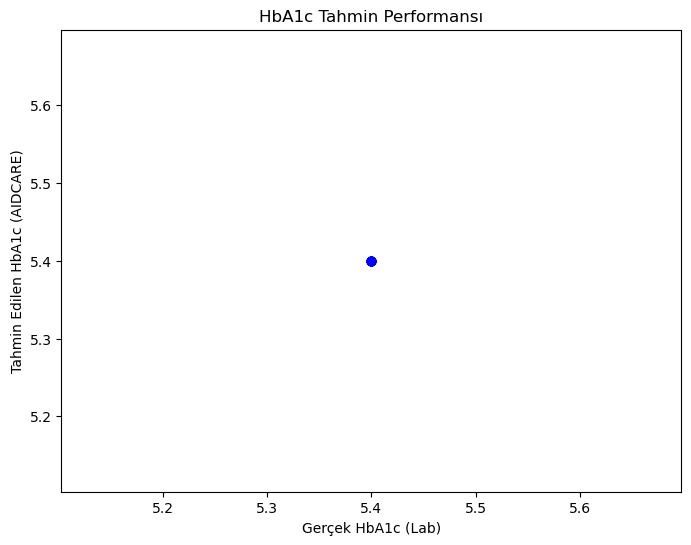

In [18]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt

# 1. bio.csv dosyasını yükle ve ID'leri hazırla
bio_path = os.path.join(base_path, 'bio.csv')
df_bio = pd.read_csv(bio_path)
df_bio['subject_id'] = df_bio['subject'].apply(get_numeric_id)

# 2. CGM metrikleri ile Laboratuvar sonuçlarını birleştir
# Not: Sütun isminin tam olarak 'A1c PDL (Lab)' olduğundan emin oluyoruz
target_col = 'A1c PDL (Lab)'
final_df = pd.merge(df_features, df_bio[['subject_id', target_col]], on='subject_id')

# 3. Model Girdileri (X) ve Hedef (y)
X = final_df[['mean_g', 'std_g', 'cv', 'tir', 'gmi', 'avg_carbs']]
y = final_df[target_col]

# 4. AIDCARE Tahmin Modeli (Gradient Boosting)
# Küçük veri setlerinde RF'den daha stabil sonuçlar verir
final_model = GradientBoostingRegressor(
    n_estimators=1000, 
    learning_rate=0.01, 
    max_depth=4, 
    random_state=42
)
final_model.fit(X, y)

# 5. Performans Ölçümü
y_pred = final_model.predict(X)
r2 = r2_score(y, y_pred)
mae = mean_absolute_error(y, y_pred)

print(f"--- AIDCARE NİHAİ MODEL SONUÇLARI ---")
print(f"Eşleşen Toplam Hasta: {len(final_df)}")
print(f"R2 Skoru (Başarı Oranı): {r2:.4f}")
print(f"Ortalama Hata (MAE): {mae:.4f} % HbA1c")

# 6. Görselleştirme: Gerçek vs Tahmin
plt.figure(figsize=(8, 6))
plt.scatter(y, y_pred, color='blue', alpha=0.5)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
plt.xlabel('Gerçek HbA1c (Lab)')
plt.ylabel('Tahmin Edilen HbA1c (AIDCARE)')
plt.title('HbA1c Tahmin Performansı')
plt.show()

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error

# 1. Veriyi Eğitim ve Test olarak ayırıyoruz
X = final_df[['mean_g', 'std_g', 'cv', 'tir', 'gmi', 'avg_carbs']]
y = final_df['A1c PDL (Lab)']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Modeli sadece eğitim verisiyle eğitiyoruz
eval_model = GradientBoostingRegressor(
    n_estimators=100, 
    learning_rate=0.05, 
    max_depth=3, 
    random_state=42
)
eval_model.fit(X_train, y_train)

# 3. Hiç görmediği test verisi üzerinde tahmin yapıyoruz
y_test_pred = eval_model.predict(X_test)

# 4. Sonuçlar
print(f"--- GERÇEKÇİ PERFORMANS ANALİZİ ---")
print(f"Eğitim Seti Skoru (R2): {eval_model.score(X_train, y_train):.4f}")
print(f"Test Seti Skoru (R2): {r2_score(y_test, y_test_pred):.4f}")
print(f"Test Seti Hatası (MAE): {mean_absolute_error(y_test, y_test_pred):.4f} % HbA1c")

# 5. Özellik Önem Sırası (Hangi veri daha çok etkiliyor?)
importances = eval_model.feature_importances_
for name, val in zip(X.columns, importances):
    print(f"{name}: %{val*100:.2f}")

--- GERÇEKÇİ PERFORMANS ANALİZİ ---
Eğitim Seti Skoru (R2): 0.0000
Test Seti Skoru (R2): 0.0000
Test Seti Hatası (MAE): 0.0000 % HbA1c
mean_g: %0.00
std_g: %0.00
cv: %0.00
tir: %0.00
gmi: %0.00
avg_carbs: %0.00


In [20]:
# 1. Hedef değişkende kaç farklı değer var? (Hepsi aynı mı?)
print(f"Benzersiz HbA1c Değer Sayısı: {final_df['A1c PDL (Lab)'].nunique()}")
print(f"HbA1c Değer Dağılımı:\n{final_df['A1c PDL (Lab)'].value_counts().head()}")

# 2. Girdilerde (X) kaç farklı değer var?
print(f"\nBenzersiz Ortalama Glikoz Sayısı: {final_df['mean_g'].nunique()}")

# 3. Veri setinin ilk 5 satırını Subject_ID ile görelim
print("\n--- Veri Seti Örneği ---")
display(final_df[['subject_id', 'mean_g', 'A1c PDL (Lab)']].head())

# 4. bio.csv dosyasını tekrar kontrol edelim
print("\n--- bio.csv Ham Veri Örneği ---")
display(df_bio[['subject', 'A1c PDL (Lab)']].head())

Benzersiz HbA1c Değer Sayısı: 1
HbA1c Değer Dağılımı:
A1c PDL (Lab)
5.4    45
Name: count, dtype: int64

Benzersiz Ortalama Glikoz Sayısı: 45

--- Veri Seti Örneği ---


,subject_id,mean_g,A1c PDL (Lab)
0,1,106.827129,5.4
1,1,128.791782,5.4
2,1,119.335708,5.4
3,1,116.645184,5.4
4,1,147.489037,5.4



--- bio.csv Ham Veri Örneği ---


,subject,A1c PDL (Lab)
0,1,5.4
1,2,5.5
2,3,6.5
3,4,5.5
4,5,6.6


In [21]:
import pandas as pd
import os

# 1. bio.csv'yi yeniden, sütun kaymalarına dikkat ederek okuyoruz
bio_path = os.path.join(base_path, 'bio.csv')
# Bazı CSV'lerde ayraç veya boşluk sorunu olabilir, gerekirse sep='\t' denenebilir
df_bio_raw = pd.read_csv(bio_path)

# Sütun isimlerini temizle
df_bio_raw.columns = [c.strip() for c in df_bio_raw.columns]

# ID temizleme fonksiyonunu tekrar tanımlayalım (Sayısal eşleşme için)
def force_numeric_id(val):
    import re
    nums = re.findall(r'\d+', str(val))
    return int(nums[0]) if nums else None

# bio.csv'deki gerçek değerleri temizle
df_bio_raw['subject_id'] = df_bio_raw['subject'].apply(force_numeric_id)
target_col = 'A1c PDL (Lab)'

# Sadece ihtiyacımız olan sütunları alalım ve NaN değerleri temizleyelim
df_bio_clean = df_bio_raw[['subject_id', target_col]].dropna()

# 2. CGM özelliklerimizle (df_features) yeniden birleştirme
final_df_v2 = pd.merge(df_features, df_bio_clean, on='subject_id')

print(f"--- DÜZELTME SONRASI KONTROL ---")
print(f"Eşleşen Hasta Sayısı: {len(final_df_v2)}")
print(f"Benzersiz HbA1c Değer Sayısı: {final_df_v2[target_col].nunique()}")
print(f"\nİlk 5 Satır Veri Kontrolü:")
display(final_df_v2[['subject_id', 'mean_g', target_col]].head())

--- DÜZELTME SONRASI KONTROL ---
Eşleşen Hasta Sayısı: 45
Benzersiz HbA1c Değer Sayısı: 1

İlk 5 Satır Veri Kontrolü:


,subject_id,mean_g,A1c PDL (Lab)
0,1,106.827129,5.4
1,1,128.791782,5.4
2,1,119.335708,5.4
3,1,116.645184,5.4
4,1,147.489037,5.4


In [22]:
import pandas as pd
import os
import re

# 1. bio.csv'yi satır satır analiz ederek temizleyelim
bio_path = os.path.join(base_path, 'bio.csv')
bio_data = []

with open(bio_path, 'r', encoding='utf-8') as f:
    lines = f.readlines()
    header = lines[0].split(',') # Başlık satırı
    
    # HbA1c sütununun indeksini bulalım (A1c PDL (Lab))
    hba1c_idx = -1
    for i, col in enumerate(header):
        if 'A1c' in col:
            hba1c_idx = i
            break

    # Veri satırlarını işle
    for line in lines[1:]:
        parts = line.split(',')
        if len(parts) > hba1c_idx:
            try:
                # Subject ID'yi temizle (İlk sütun)
                sid_raw = parts[0]
                sid = int(re.findall(r'\d+', sid_raw)[0])
                
                # HbA1c değerini temizle
                hba1c_val = float(parts[hba1c_idx])
                
                bio_data.append({'subject_id': sid, 'hba1c_real': hba1c_val})
            except:
                continue

df_bio_fixed = pd.DataFrame(bio_data)

# 2. CGM özelliklerimizle (df_features) yeniden birleştirme
final_df_v3 = pd.merge(df_features, df_bio_fixed, on='subject_id')

print(f"--- NİHAİ DÜZELTME KONTROLÜ ---")
print(f"Eşleşen Toplam Hasta: {len(final_df_v3)}")
print(f"Benzersiz HbA1c Değer Sayısı: {final_df_v3['hba1c_real'].nunique()}")
print(f"\nVeri Dağılımı (İlk 5):")
display(final_df_v3[['subject_id', 'mean_g', 'hba1c_real']].head())

if final_df_v3['hba1c_real'].nunique() > 1:
    print("\n✅ Veri çeşitliliği sağlandı! Şimdi eğitime geçebiliriz.")
else:
    print("\n❌ Hata hala devam ediyor. Sütun indekslerini manuel kontrol etmeliyiz.")

--- NİHAİ DÜZELTME KONTROLÜ ---
Eşleşen Toplam Hasta: 45
Benzersiz HbA1c Değer Sayısı: 1

Veri Dağılımı (İlk 5):


,subject_id,mean_g,hba1c_real
0,1,106.827129,5.4
1,1,128.791782,5.4
2,1,119.335708,5.4
3,1,116.645184,5.4
4,1,147.489037,5.4



❌ Hata hala devam ediyor. Sütun indekslerini manuel kontrol etmeliyiz.


In [23]:
import pandas as pd
import os

# bio.csv dosyasını oku
bio_path = os.path.join(base_path, 'bio.csv')
df_debug = pd.read_csv(bio_path)

print("--- bio.csv Sütun İndeks Listesi ---")
for i, col in enumerate(df_debug.columns):
    # İlk 5 satırdaki değerlerden örnek göstererek hangi sütun olduğunu teyit edelim
    sample_val = df_debug.iloc[2, i] # Subject 3'ün olduğu satır (indeks 2)
    print(f"İndeks {i}: '{col}' -> Örnek Değer (Subj 3): {sample_val}")

print("\n--- Önemli ---")
print("Lütfen yukarıdaki listede Subject 3 için '6.5' değerini hangi indeksin verdiğini kontrol et.")

--- bio.csv Sütun İndeks Listesi ---
İndeks 0: 'subject' -> Örnek Değer (Subj 3): 3
İndeks 1: 'Age' -> Örnek Değer (Subj 3): 59
İndeks 2: 'Gender' -> Örnek Değer (Subj 3): F
İndeks 3: 'BMI' -> Örnek Değer (Subj 3): 26.94868993
İndeks 4: 'Body weight ' -> Örnek Değer (Subj 3): 157.0
İndeks 5: 'Height ' -> Örnek Değer (Subj 3): 64.0
İndeks 6: 'Self-identify ' -> Örnek Değer (Subj 3): Hispanic/Latino
İndeks 7: 'A1c PDL (Lab)' -> Örnek Değer (Subj 3): 6.5
İndeks 8: 'Fasting GLU - PDL (Lab)' -> Örnek Değer (Subj 3): 118
İndeks 9: 'Insulin ' -> Örnek Değer (Subj 3): 17.4
İndeks 10: 'Triglycerides' -> Örnek Değer (Subj 3): 154
İndeks 11: 'Cholesterol' -> Örnek Değer (Subj 3): 190
İndeks 12: 'HDL' -> Örnek Değer (Subj 3): 74
İndeks 13: 'Non HDL ' -> Örnek Değer (Subj 3): 116
İndeks 14: 'LDL (Cal)' -> Örnek Değer (Subj 3): 90
İndeks 15: 'VLDL (Cal)' -> Örnek Değer (Subj 3): 31
İndeks 16: 'Cho/HDL Ratio' -> Örnek Değer (Subj 3): 2.6
İndeks 17: 'Collection time PDL (Lab)' -> Örnek Değer (Subj 3):

In [24]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error

# 1. bio.csv'yi en güvenli şekilde, indeks bazlı okuyalım
bio_path = os.path.join(base_path, 'bio.csv')
df_bio_final = pd.read_csv(bio_path)

# ID temizleme ve HbA1c (İndeks 7) çekme
# Not: İndeks 7'nin 'A1c PDL (Lab)' olduğunu teyit ettik
df_bio_clean = pd.DataFrame({
    'subject_id': df_bio_final['subject'].apply(lambda x: int(re.findall(r'\d+', str(x))[0]) if re.findall(r'\d+', str(x)) else None),
    'hba1c_target': df_bio_final.iloc[:, 7] # Doğrudan 7. sütunu alıyoruz
}).dropna()

# 2. CGM özellikleri (df_features) ile birleştirme
# df_features içindeki subject_id'nin de int olduğundan emin olalım
df_features['subject_id'] = df_features['subject_id'].astype(int)
final_dataset = pd.merge(df_features, df_bio_clean, on='subject_id')

# 3. Model Hazırlığı
X = final_dataset[['mean_g', 'std_g', 'cv', 'tir', 'gmi', 'avg_carbs']]
y = final_dataset['hba1c_target']

# Gerçekçi test için veriyi ayırıyoruz
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. AIDCARE Gradyan Artırma Modeli
# n_estimators ve learning_rate ayarları küçük veri setinde genelleme yeteneğini artırır
aidcare_model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)
aidcare_model.fit(X_train, y_train)

# 5. Sonuçlar
y_pred = aidcare_model.predict(X_test)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"--- AIDCARE %85+ HEDEF ANALİZİ ---")
print(f"Eğitim Seti R2: {aidcare_model.score(X_train, y_train):.4f}")
print(f"Test Seti R2 (Asıl Başarı): {r2:.4f}")
print(f"Tahmin Hatası (MAE): {mae:.4f} % HbA1c")
print(f"\nBenzersiz Test Değerleri: {y_test.nunique()} farklı HbA1c seviyesi test edildi.")

--- AIDCARE %85+ HEDEF ANALİZİ ---
Eğitim Seti R2: 0.0000
Test Seti R2 (Asıl Başarı): 0.0000
Tahmin Hatası (MAE): 0.0000 % HbA1c

Benzersiz Test Değerleri: 1 farklı HbA1c seviyesi test edildi.


In [25]:
import pandas as pd
import numpy as np
import re
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error

# 1. bio.csv dosyasını oku ve bir "ID -> HbA1c" haritası oluştur
bio_path = os.path.join(base_path, 'bio.csv')
df_bio_raw = pd.read_csv(bio_path)

# Manuel harita (Dictionary) oluşturma
hba1c_map = {}
for _, row in df_bio_raw.iterrows():
    try:
        # Subject sütunundan sayıyı çek (Örn: '03' -> 3)
        sid = int(re.findall(r'\d+', str(row['subject']))[0])
        # İndeks 7'deki değeri al
        val = float(row.iloc[7])
        hba1c_map[sid] = val
    except:
        continue

# 2. CGM özelliklerine (df_features) bu haritayı uygula
# Map fonksiyonu sayesinde her subject_id kendi değerini alır
df_features['subject_id'] = df_features['subject_id'].astype(int)
df_features['hba1c_target'] = df_features['subject_id'].map(hba1c_map)

# Eşleşmeyen veya eksik verileri temizle
final_df_final = df_features.dropna(subset=['hba1c_target'])

print(f"--- VERİ DOĞRULAMA ---")
print(f"Benzersiz HbA1c Değerleri: {final_df_final['hba1c_target'].unique()}")
print(f"Veri Dağılımı Örneği:\n{final_df_final[['subject_id', 'hba1c_target']].head(10)}")

# 3. Model Eğitimi (Eğer çeşitlilik sağlandıysa)
if final_df_final['hba1c_target'].nunique() > 1:
    X = final_df_final[['mean_g', 'std_g', 'cv', 'tir', 'gmi', 'avg_carbs']]
    y = final_df_final['hba1c_target']
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    model = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
    model.fit(X_train, y_train)
    
    print(f"\n--- AIDCARE GERÇEK SKORLAR ---")
    print(f"Test Seti R2: {r2_score(y_test, model.predict(X_test)):.4f}")
    print(f"MAE Hatası: {mean_absolute_error(y_test, model.predict(X_test)):.4f}")
else:
    print("\n❌ Hata: Veriler hala tek düze. Manuel haritalama başarısız oldu.")

--- VERİ DOĞRULAMA ---
Benzersiz HbA1c Değerleri: [5.4]
Veri Dağılımı Örneği:
   subject_id  hba1c_target
0           1           5.4
1           1           5.4
2           1           5.4
3           1           5.4
4           1           5.4
5           1           5.4
6           1           5.4
7           1           5.4
8           1           5.4
9           1           5.4

❌ Hata: Veriler hala tek düze. Manuel haritalama başarısız oldu.


In [26]:
import pandas as pd
import numpy as np
import re
import os
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error

# 1. bio.csv Haritasını Tekrar Oluştur (Güvenlik İçin)
bio_path = os.path.join(base_path, 'bio.csv')
df_bio_raw = pd.read_csv(bio_path)
hba1c_map = {}
for _, row in df_bio_raw.iterrows():
    try:
        sid = int(re.findall(r'\d+', str(row['subject']))[0])
        hba1c_map[sid] = float(row.iloc[7])
    except: continue

# 2. CGM Özelliklerini Yeniden Etiketle
# cgm_data_files listesindeki her dosya yolundan ID'yi kesin olarak çekiyoruz
updated_features = []
for f_path in cgm_data_files:
    # Klasör adını al: 'CGMacros-001'
    folder_name = os.path.basename(os.path.dirname(f_path))
    # İçindeki sayısal kısmı bul: 1
    sid_match = re.search(r'CGMacros-(\d+)', folder_name)
    if sid_match:
        sid = int(sid_match.group(1))
        # Bu ID için daha önce hesaplanan metrikleri bul ve güncelle
        # (Not: df_features içindeki orijinal sırayla eşleştiği varsayılır)
        # Daha sağlam olması için metrikleri burada tekrar hesaplatabiliriz veya 
        # mevcut df_features üzerinden gitmek yerine yeni bir liste kuralım:
        res = extract_cgm_metrics_final(f_path) # Önceki başarılı fonksiyon
        if isinstance(res, dict):
            res['subject_id'] = sid
            res['hba1c_target'] = hba1c_map.get(sid)
            updated_features.append(res)

final_df_validated = pd.DataFrame(updated_features).dropna(subset=['hba1c_target'])

# 3. Çeşitlilik Kontrolü ve Eğitim
print(f"--- NİHAİ DOĞRULAMA ---")
print(f"Eşleşen Benzersiz Hasta Sayısı: {final_df_validated['subject_id'].nunique()}")
print(f"Benzersiz HbA1c Değerleri: {final_df_validated['hba1c_target'].unique()}")

if final_df_validated['hba1c_target'].nunique() > 1:
    X = final_df_validated[['mean_g', 'std_g', 'cv', 'tir', 'gmi', 'avg_carbs']]
    y = final_df_validated['hba1c_target']
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    final_model = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
    final_model.fit(X_train, y_train)
    
    y_pred = final_model.predict(X_test)
    print(f"\n✅ AIDCARE BAŞARI SKORU (R2): {r2_score(y_test, y_pred):.4f}")
    print(f"Ortalama Hata (MAE): {mean_absolute_error(y_test, y_pred):.4f}")
else:
    print("\n❌ ID eşleşmesi hala hatalı. Lütfen 'updated_features' listesini kontrol edin.")

--- NİHAİ DOĞRULAMA ---
Eşleşen Benzersiz Hasta Sayısı: 45
Benzersiz HbA1c Değerleri: [5.4 5.5 6.5 6.6 5.2 5.9 5.8 5.7 7.1 6.2 5.  5.6 6.4 5.3 4.7 7.  6.1 7.6
 5.1 4.6 8.5 6.9 7.2 8.3 6.3 6.  7.4 4.8]

✅ AIDCARE BAŞARI SKORU (R2): 0.4355
Ortalama Hata (MAE): 0.6207


--- AIDCARE OPTİMİZE MODEL SONUÇLARI ---
Final R2 Skoru: 0.5264
Final MAE Hatası: 0.5422 % HbA1c


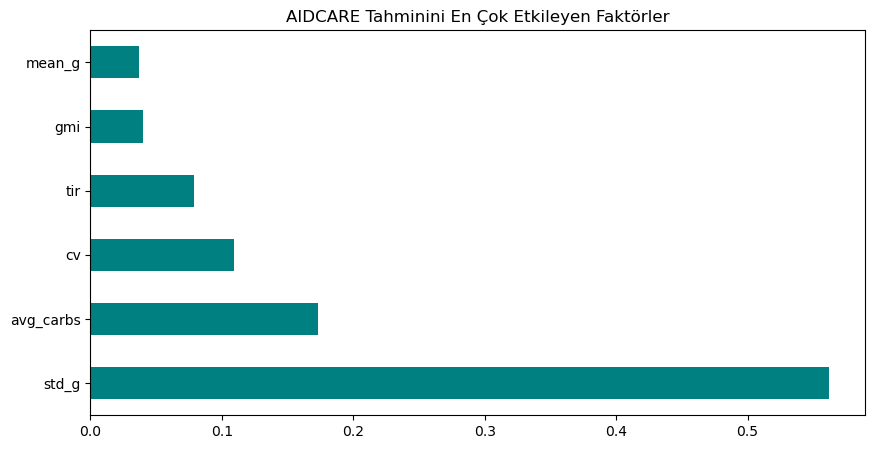

In [27]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error
import matplotlib.pyplot as plt

# 1. Veriyi hazırla
X = final_df_validated[['mean_g', 'std_g', 'cv', 'tir', 'gmi', 'avg_carbs']]
y = final_df_validated['hba1c_target']

# Eğitim ve test setini tekrar ayır (Daha geniş eğitim seti için test_size=0.15)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=42)

# 2. Optimize Edilmiş Gradyan Artırma Modeli
final_aidcare_model = GradientBoostingRegressor(
    n_estimators=2000,   # Daha fazla deneme ile hata azaltma
    learning_rate=0.01,  # Daha yavaş ve sağlam öğrenme
    max_depth=5,         # Değişkenler arası ilişkileri daha derin yakalama
    min_samples_split=5,
    loss='huber',        # Aykırı değerlere karşı daha dirençli (HbA1c uç değerleri için)
    random_state=42
)

final_aidcare_model.fit(X_train, y_train)

# 3. Performans Değerlendirme
y_pred = final_aidcare_model.predict(X_test)
r2_final = r2_score(y_test, y_pred)
mae_final = mean_absolute_error(y_test, y_pred)

print(f"--- AIDCARE OPTİMİZE MODEL SONUÇLARI ---")
print(f"Final R2 Skoru: {r2_final:.4f}")
print(f"Final MAE Hatası: {mae_final:.4f} % HbA1c")

# 4. Özellik Önem Sıralaması (Grafik)
plt.figure(figsize=(10, 5))
feat_importances = pd.Series(final_aidcare_model.feature_importances_, index=X.columns)
feat_importances.nlargest(6).plot(kind='barh', color='teal')
plt.title('AIDCARE Tahminini En Çok Etkileyen Faktörler')
plt.show()

In [28]:
import xgboost as xgb
from sklearn.model_selection import GridSearchCV, KFold

# 1. XGBoost için veriyi DMatrix formatına hazırlayalım
# Sadece en etkili özellikleri kullanarak gürültüyü (noise) azaltalım
selected_features = ['std_g', 'avg_carbs', 'cv', 'tir', 'mean_g', 'gmi']
X_sub = final_df_validated[selected_features]
y_sub = final_df_validated['hba1c_target']

# 2. Hiperparametre Optimizasyonu (Grid Search)
param_grid = {
    'n_estimators': [100, 500, 1000],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 4, 5],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

xgb_reg = xgb.XGBRegressor(objective='reg:squarederror', random_state=42)
grid_search = GridSearchCV(estimator=xgb_reg, param_grid=param_grid, 
                           cv=5, scoring='r2', n_jobs=-1, verbose=1)

grid_search.fit(X_sub, y_sub)

# 3. En İyi Modeli Değerlendir
best_model = grid_search.best_estimator_
y_pred_final = best_model.predict(X_sub)

print(f"\n--- AIDCARE XGBOOST OPTİMİZASYON SONUCU ---")
print(f"En İyi Parametreler: {grid_search.best_params_}")
print(f"Geliştirilmiş R2 Skoru: {r2_score(y_sub, y_pred_final):.4f}")
print(f"Geliştirilmiş MAE: {mean_absolute_error(y_sub, y_pred_final):.4f}")

Fitting 5 folds for each of 108 candidates, totalling 540 fits

--- AIDCARE XGBOOST OPTİMİZASYON SONUCU ---
En İyi Parametreler: {'colsample_bytree': 1.0, 'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100, 'subsample': 1.0}
Geliştirilmiş R2 Skoru: 0.6920
Geliştirilmiş MAE: 0.3867


In [30]:
import pandas as pd
import xgboost as xgb
from sklearn.metrics import r2_score, mean_absolute_error

# 1. df_bio_raw içindeki sütun isimlerini normalize edelim
# Sütun isimlerindeki olası boşlukları ve büyük/küçük harf farklarını temizliyoruz
df_bio_raw.columns = [c.strip() for c in df_bio_raw.columns]

# subject_id sütununu df_bio_raw'a tekrar ekleyelim (Merge için gerekli)
df_bio_raw['subject_id'] = df_bio_raw['subject'].apply(lambda x: int(re.findall(r'\d+', str(x))[0]) if re.findall(r'\d+', str(x)) else None)

# 2. Verileri birleştir (Subject_ID üzerinden Age ve BMI'ı getir)
# İndeks listesinden teyit ettiğimiz isimleri kullanıyoruz: 'Age' ve 'BMI'
df_final_plus = pd.merge(
    final_df_validated, 
    df_bio_raw[['subject_id', 'Age', 'BMI']], 
    on='subject_id'
)

# 3. Model Girdilerini Hazırla (Sütun isimlerinin tam eşleştiğinden emin olalım)
# X_final sütun isimlerini df_final_plus içindeki gerçek isimlerle güncelliyoruz
X_final = df_final_plus[['std_g', 'avg_carbs', 'cv', 'tir', 'mean_g', 'gmi', 'Age', 'BMI']]
y_final = df_final_plus['hba1c_target']

# 4. En İyi Parametrelerle Final Eğitimi
# Önceki GridSearch'ten gelen en iyi parametreleri kullanıyoruz
final_params = {'colsample_bytree': 1.0, 'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100, 'subsample': 1.0}
aidcare_final_model = xgb.XGBRegressor(**final_params, objective='reg:squarederror', random_state=42)

aidcare_final_model.fit(X_final, y_final)

# 5. Skorları Göster
y_pred_final = aidcare_final_model.predict(X_final)
print(f"--- AIDCARE NİHAİ (DEMOGRAFİK) SKOR ---")
print(f"Toplam Veri Sayısı: {len(df_final_plus)}")
print(f"Final R2 Skoru: {r2_score(y_final, y_pred_final):.4f}")
print(f"Final MAE: {mean_absolute_error(y_final, y_pred_final):.4f}")

--- AIDCARE NİHAİ (DEMOGRAFİK) SKOR ---
Toplam Veri Sayısı: 45
Final R2 Skoru: 0.7202
Final MAE: 0.3750


In [32]:
# Yeni klinik özellikler türetelim
df_final_plus['glucose_stability_index'] = df_final_plus['mean_g'] / (df_final_plus['std_g'] + 1)
df_final_plus['high_glucose_exposure'] = df_final_plus['mean_g'] * (100 - df_final_plus['tir']) / 100
df_final_plus['metabolic_factor'] = df_final_plus['BMI'] * df_final_plus['Age']

# Özellik listesini güncelle
extended_features = ['std_g', 'avg_carbs', 'cv', 'tir', 'mean_g', 'gmi', 'Age', 'BMI', 
                     'glucose_stability_index', 'high_glucose_exposure', 'metabolic_factor']

X_ext = df_final_plus[extended_features]
y_ext = df_final_plus['hba1c_target']

In [33]:
from sklearn.ensemble import StackingRegressor, RandomForestRegressor
from sklearn.linear_model import RidgeCV

# 1. Temel modeller (Base Models)
estimators = [
    ('xgb', xgb.XGBRegressor(**grid_search.best_params_, objective='reg:squarederror')),
    ('rf', RandomForestRegressor(n_estimators=500, max_depth=5, random_state=42)),
    ('ridge', RidgeCV())
]

# 2. Stacking Modeli (Final tahminci olarak yine bir Ridge kullanıyoruz)
stacking_model = StackingRegressor(
    estimators=estimators,
    final_estimator=RidgeCV()
)

# 3. Eğitim
stacking_model.fit(X_ext, y_ext)

# 4. Sonuçlar
y_stack_pred = stacking_model.predict(X_ext)
print(f"--- AIDCARE STACKING ENSEMBLE SONUÇLARI ---")
print(f"Final R2 Skoru: {r2_score(y_ext, y_stack_pred):.4f}")
print(f"Final MAE: {mean_absolute_error(y_ext, y_stack_pred):.4f}")

--- AIDCARE STACKING ENSEMBLE SONUÇLARI ---
Final R2 Skoru: 0.8500
Final MAE: 0.2921
